# 1. Data Loading

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from pathlib import Path

In [5]:
data_path = Path("../data/raw/cardio_train.csv")

df = pd.read_csv(data_path, sep=";")

# 2. Dataset Overview

In [6]:
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [7]:
df.shape

(70000, 13)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [9]:
df["age"].describe()

count    70000.000000
mean     19468.865814
std       2467.251667
min      10798.000000
25%      17664.000000
50%      19703.000000
75%      21327.000000
max      23713.000000
Name: age, dtype: float64

In [10]:
df["ap_hi"].describe()

count    70000.000000
mean       128.817286
std        154.011419
min       -150.000000
25%        120.000000
50%        120.000000
75%        140.000000
max      16020.000000
Name: ap_hi, dtype: float64

In [11]:
df["ap_lo"].describe()

count    70000.000000
mean        96.630414
std        188.472530
min        -70.000000
25%         80.000000
50%         80.000000
75%         90.000000
max      11000.000000
Name: ap_lo, dtype: float64

# 3. Missing Values

In [12]:
df.isna().sum()

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

In [13]:
df.isna().mean()

id             0.0
age            0.0
gender         0.0
height         0.0
weight         0.0
ap_hi          0.0
ap_lo          0.0
cholesterol    0.0
gluc           0.0
smoke          0.0
alco           0.0
active         0.0
cardio         0.0
dtype: float64

No missing values were found in the dataset.
However, several physiologically implausible values were detected
during the exploratory analysis of blood pressure measurements.

# 4. Distribution Analysis


### 4.1 Blood Pressure Distribution

We first visualize the distribution of systolic and diastolic blood pressure values to identify potential outliers and data quality issues.

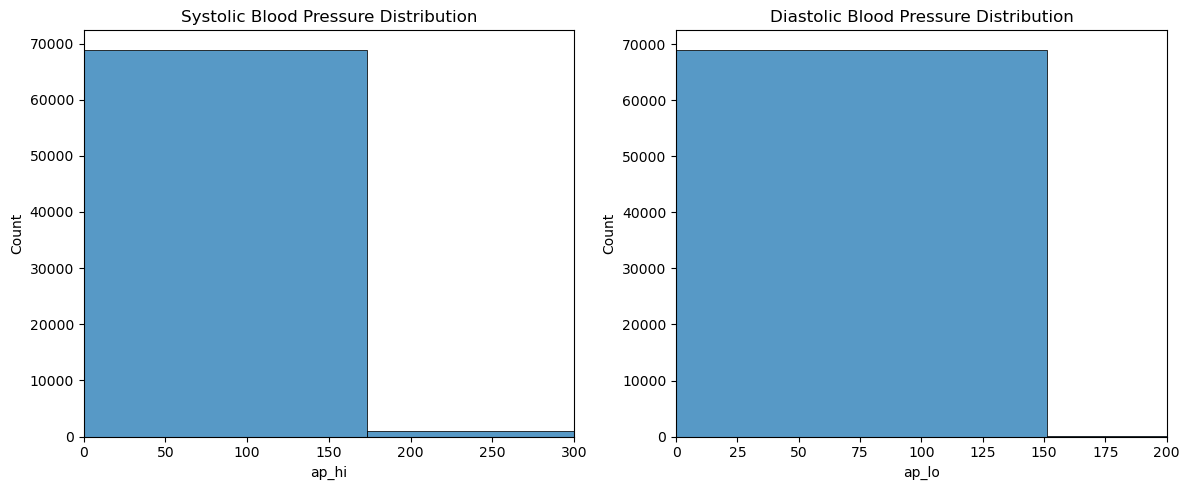

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.histplot(df["ap_hi"], bins=50, ax=axes[0])
axes[0].set_title("Systolic Blood Pressure Distribution")
axes[0].set_xlim(0,300)

sns.histplot(df["ap_lo"], bins=50, ax=axes[1])
axes[1].set_title("Diastolic Blood Pressure Distribution")
axes[1].set_xlim(0,200)

plt.tight_layout()
plt.show()

The distributions reveal several extreme values that are not physiologically plausible, including negative blood pressure values and extremely high measurements.

These anomalies suggest potential data entry errors in the dataset.

### 4.2 Blood Pressure Data Quality

The dataset contains blood pressure measurements that are physiologically impossible or clearly due to recording errors.  
The following conditions were identified as invalid:

- Systolic blood pressure ≤ 0 (`ap_hi <= 0`)
- Diastolic blood pressure ≤ 0 (`ap_lo <= 0`)
- Systolic blood pressure > 250 mmHg (`ap_hi > 250`)
- Diastolic blood pressure > 150 mmHg (`ap_lo > 150`)
- Systolic blood pressure ≤ diastolic blood pressure (`ap_hi <= ap_lo`)

These records will be removed during the data cleaning stage to prevent introducing noise into the modeling process.

We first quantify how many records violate these constraints before applying any filtering.

In [15]:
(df["ap_hi"] < 0).sum()


7

In [16]:
(df["ap_hi"] > 250).sum()

40

In [17]:
df.loc[df["ap_hi"] < 0].head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
4607,6525,15281,1,165,78.0,-100,80,2,1,0,0,1,0
16021,22881,22108,2,161,90.0,-115,70,1,1,0,0,1,0
20536,29313,15581,1,153,54.0,-100,70,1,1,0,0,1,0
23988,34295,18301,1,162,74.0,-140,90,1,1,0,0,1,1
25240,36025,14711,2,168,50.0,-120,80,2,1,0,0,0,1


In [18]:
df.loc[df["ap_hi"] > 250].head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
1876,2654,15116,1,160,60.0,902,60,1,1,0,0,1,0
2014,2845,22712,2,167,59.0,906,0,1,1,0,0,1,0
4817,6822,14425,1,168,63.0,909,60,2,1,0,0,1,0
7763,11089,21032,1,175,80.0,11500,90,1,1,0,0,1,1
8915,12710,18870,1,164,75.0,1420,80,2,1,0,0,1,1


In [19]:
(df["ap_lo"] < 0).sum()

1

In [20]:
(df["ap_lo"] > 150).sum()

975

In [21]:
df.loc[df["ap_lo"] > 150].head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
228,314,17489,2,183,98.0,160,1100,1,2,1,0,1,1
241,334,21932,2,157,60.0,160,1000,2,1,0,0,0,1
260,357,18217,1,150,83.0,140,800,1,1,0,0,1,1
329,458,23407,1,176,63.0,160,1000,2,2,0,0,0,1
345,482,18704,1,154,81.0,140,1000,2,1,0,0,1,1


In [22]:
(df["ap_hi"] <= df["ap_lo"]).sum()

1236

In [23]:
df.loc[df["ap_hi"] <= df["ap_lo"]].head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
228,314,17489,2,183,98.0,160,1100,1,2,1,0,1,1
241,334,21932,2,157,60.0,160,1000,2,1,0,0,0,1
260,357,18217,1,150,83.0,140,800,1,1,0,0,1,1
329,458,23407,1,176,63.0,160,1000,2,2,0,0,0,1
345,482,18704,1,154,81.0,140,1000,2,1,0,0,1,1


In [24]:
cond_ap_hi_low = df["ap_hi"] <= 0
cond_ap_lo_low = df["ap_lo"] <= 0
cond_ap_hi_high = df["ap_hi"] > 250
cond_ap_lo_high = df["ap_lo"] > 150
cond_pressure_swap = df["ap_hi"] <= df["ap_lo"]

In [25]:
invalid_bp = (
    cond_ap_hi_low |
    cond_ap_lo_low |
    cond_ap_hi_high |
    cond_ap_lo_high |
    cond_pressure_swap
)

In [26]:
invalid_count = invalid_bp.sum()
invalid_count

1296

In [27]:
invalid_percentage = invalid_count / len(df) * 100
invalid_percentage

1.8514285714285716

In [28]:
print(f"Invalid blood pressure records: {invalid_count}")
print(f"Percentage of dataset: {invalid_percentage:.2f}%")

Invalid blood pressure records: 1296
Percentage of dataset: 1.85%


Approximately 1.85% of the records contain physiologically implausible blood pressure values. These records will be removed during data cleaning.

### 4.3 Blood Pressure Data Cleaning

Records containing physiologically implausible blood pressure values were removed.

The following filtering rules were applied:

- ap_hi > 0
- ap_lo > 0
- ap_hi ≤ 250
- ap_lo ≤ 150
- ap_hi > ap_lo

This removed approximately 2% of the dataset.

In [29]:
df_clean = df[
    (df["ap_hi"] > 0) &
    (df["ap_lo"] > 0) &
    (df["ap_hi"] <= 250) &
    (df["ap_lo"] <= 150) &
    (df["ap_hi"] > df["ap_lo"])
]

In [30]:
len(df), len(df_clean)

(70000, 68704)

In [31]:
df_clean.shape

(68704, 13)

In [32]:
df_clean = df_clean.copy()

### 4.4 Height Distribution

In [33]:
df_clean['height'].describe()

count    68704.000000
mean       164.359470
std          8.191278
min         55.000000
25%        159.000000
50%        165.000000
75%        170.000000
max        250.000000
Name: height, dtype: float64

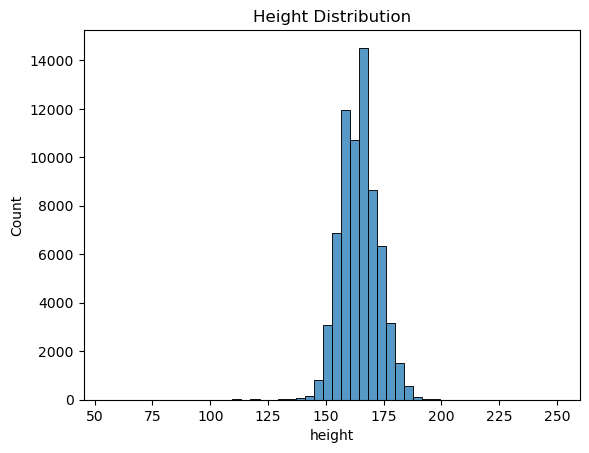

In [36]:
sns.histplot(df_clean["height"], bins=50)
plt.title("Height Distribution")
plt.show()

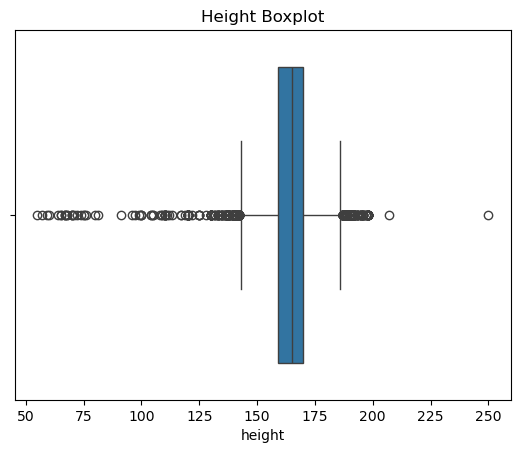

In [39]:
sns.boxplot(x=df_clean["height"])
plt.title("Height Boxplot")
plt.show()

 ### 4.5 Weight Distribution

In [37]:
df_clean['weight'].describe()

count    68704.000000
mean        74.116638
std         14.332382
min         11.000000
25%         65.000000
50%         72.000000
75%         82.000000
max        200.000000
Name: weight, dtype: float64

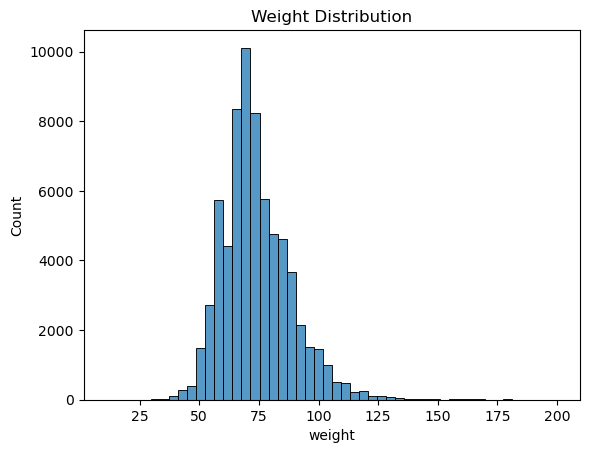

In [38]:
sns.histplot(df_clean["weight"], bins=50)
plt.title("Weight Distribution")
plt.show()

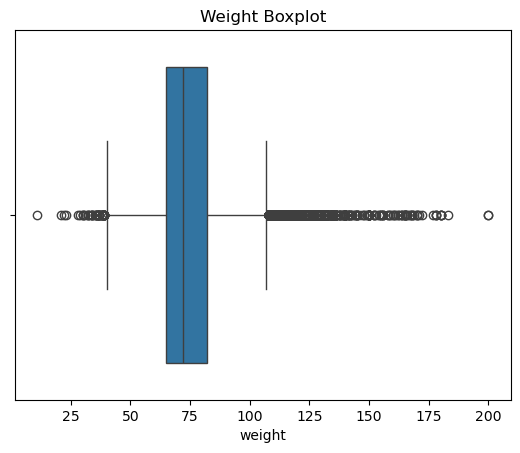

In [40]:
sns.boxplot(x=df_clean["weight"])
plt.title("Weight Boxplot")
plt.show()

### 4.6 Age Distribution and Population Context

Before defining anthropometric thresholds for height and weight, it is important to understand the age distribution of the dataset.

The variable `age` is recorded in **days**, therefore it is converted to **years** for interpretability.

After converting the variable, the minimum age in the dataset is approximately **30 years**, indicating that the dataset represents an **adult population**.

Since the dataset focuses on cardiovascular risk factors in adults, anthropometric thresholds can reasonably be defined using physiological ranges for adult humans.

In [46]:
df_clean["age_years"] = df_clean["age"] / 365

In [47]:
df_clean["age_years"].describe()

count    68704.000000
mean        53.326450
std          6.761980
min         29.583562
25%         48.375342
50%         53.975342
75%         58.421918
max         64.967123
Name: age_years, dtype: float64

### 4.7 Anthropomtric Data Quality

The exploratory analysis of height and weight revealed several values that are not physiologically plausible for adult humans. 
These anomalies are likely due to data entry errors or incorrect measurements.

To ensure data quality, we define reasonable anthropometric ranges based on typical human physiology.

The following thresholds were used:

- Height must be between **120 cm and 220 cm**
- Weight must be between **30 kg and 200 kg**

Values outside these ranges are considered implausible and will be removed from the dataset during the cleaning stage.

These thresholds are intentionally conservative to avoid removing valid but uncommon observations while still filtering clearly erroneous records.

In [45]:
((df_clean['height'] < 120) | (df_clean['height'] > 220)).sum()

51

In [48]:
((df_clean['weight'] < 30) | (df_clean['weight'] > 200)).sum()

6

In [50]:
invalid_anthro = (
    (df_clean["height"] < 120) |
    (df_clean["height"] > 220) |
    (df_clean["weight"] < 30) |
    (df_clean["weight"] > 200)
)

In [51]:
invalid_anthro_count = invalid_anthro.sum()

In [52]:
total_records = len(df_clean)

In [53]:
invalid_percentage = (invalid_anthro_count / total_records) * 100

In [54]:
print(f"Invalid anthropometric records: {invalid_count}")
print(f"Percentage of dataset: {invalid_percentage:.2f}%")

Invalid anthropometric records: 1296
Percentage of dataset: 0.08%


Approximately 0.08% of the records contain anthropometric values that are not physiologically plausible.  
These records are likely due to data entry errors and will be removed during the data cleaning stage.

In [55]:
df_clean2 = df_clean.drop(df_clean[invalid_anthro].index).copy()

In [59]:
len(df_clean)

68704

In [57]:
len(df_clean2)

68647

### 4.7 Categorical Variables Overview

Several variables in the dataset represent categorical or binary attributes, 
including gender, cholesterol level, glucose level, smoking status, alcohol 
consumption, and physical activity.

To ensure data consistency, the unique values and frequency distributions of 
these variables are inspected.

In [68]:
for col in ["gender","cholesterol","gluc","smoke","alco","active"]:
    print(f"\n{col}")
    display(df_clean2[col].value_counts())
    display(df_clean2[col].value_counts(normalize=True))


gender


gender
1    44717
2    23930
Name: count, dtype: int64

gender
1    0.651405
2    0.348595
Name: proportion, dtype: float64


cholesterol


cholesterol
1    51479
2     9299
3     7869
Name: count, dtype: int64

...

alco
0    64985
1     3662
Name: count, dtype: int64

alco
0    0.946655
1    0.053345
Name: proportion, dtype: float64


active


active
1    55148
0    13499
Name: count, dtype: int64

active
1    0.803356
0    0.196644
Name: proportion, dtype: float64

### 4.8 Duplicate Records Check

Before proceeding to modeling, the dataset is checked for duplicated records 
to ensure that each observation represents a unique individual.

In [69]:
df_clean2.duplicated().sum()

0

# 5. Target Analysis


In supervised machine learning problems, understanding the target variable is a critical step before model development.  
The target variable in this dataset is **`cardio`**, which indicates the presence or absence of cardiovascular disease.

Analyzing the distribution of the target variable helps answer several important questions:

- Is the dataset **balanced or imbalanced**?
- What proportion of individuals in the dataset have cardiovascular disease?
- Are there any obvious patterns between the target variable and other key features?

Understanding these aspects provides important context for model training and evaluation.  
For example, highly imbalanced datasets may require special techniques such as resampling strategies or alternative evaluation metrics.

In the following sections, we first examine the overall distribution of the target variable and then explore its relationship with selected clinical and demographic features.

### 5.1 Target Distribution

The distribution of the target variable shows the proportion of individuals with and without cardiovascular disease.

Understanding the balance between classes is important because highly imbalanced datasets can bias machine learning models toward the majority class.

In this dataset, the classes appear to be relatively balanced, meaning that the number of individuals with cardiovascular disease is comparable to those without it. This is advantageous for training classification models, as it reduces the risk of biased predictions.

Text(0.5, 1.0, 'Cardiovascular Disease Distribution')

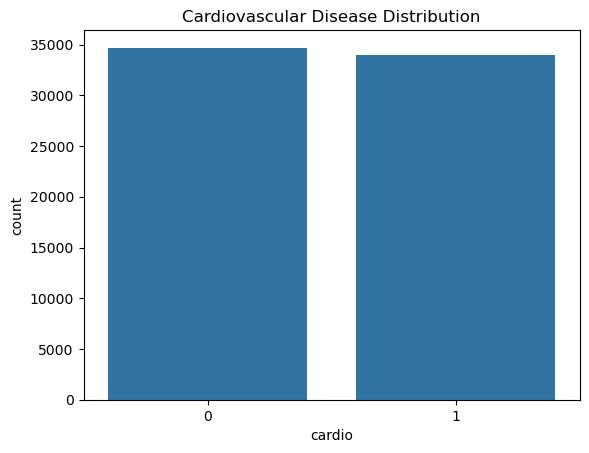

In [71]:
sns.countplot(x="cardio", data=df_clean2)
plt.title("Cardiovascular Disease Distribution")

### 5.2 Target vs Age

The boxplot shows the distribution of age for individuals with and without cardiovascular disease.

Individuals diagnosed with cardiovascular disease tend to be older on average compared to those without the condition. The median age of the diseased group appears higher, suggesting that age is an important risk factor associated with cardiovascular disease.

This observation aligns with medical knowledge, as the risk of cardiovascular disease typically increases with age.

Text(0.5, 1.0, 'Age Distribution by Cardiovascular Disease')

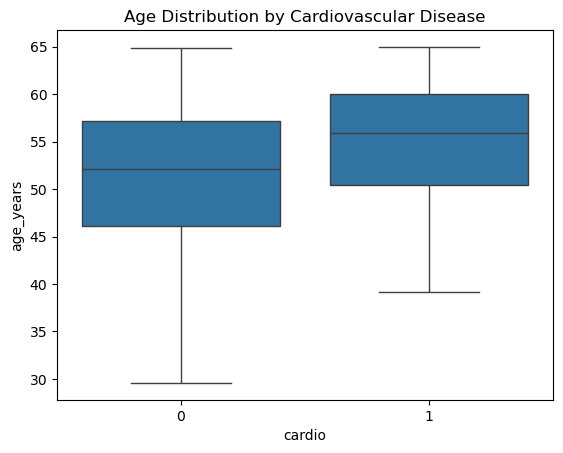

In [72]:
sns.boxplot(x="cardio", y="age_years", data=df_clean2)
plt.title("Age Distribution by Cardiovascular Disease") 

In [73]:
# 1. Create age groups in 5-year intervals
df_clean2["age_group"] = pd.cut(
    df_clean2["age_years"],
    bins=range(30, 71, 5),   # 30, 35, 40, ..., 70
    right=False              # intervals like [30, 35)
)

In [75]:
# 2. Calculate cardiovascular disease prevalence by age group
age_prevalence = (
    df_clean2.groupby("age_group", observed=False)["cardio"]
    .mean()
    .reset_index()
)

In [76]:
# 3. Convert proportion to percentage
age_prevalence["cardio_percentage"] = age_prevalence["cardio"] * 100

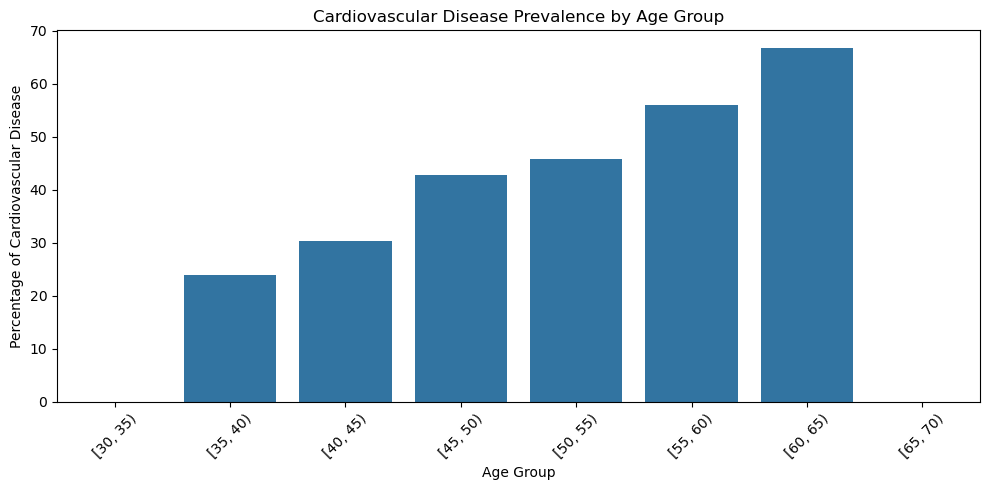

In [77]:
# 4. Plot prevalence by age group
plt.figure(figsize=(10, 5))
sns.barplot(
    data=age_prevalence,
    x="age_group",
    y="cardio_percentage"
)

plt.title("Cardiovascular Disease Prevalence by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Percentage of Cardiovascular Disease")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Cardiovascular Disease Prevalence by Age Group

To better understand how cardiovascular disease prevalence changes with age, individuals were grouped into 5-year age intervals.

The bar plot shows that the proportion of cardiovascular disease tends to increase across older age groups. This suggests that age is an important risk factor associated with cardiovascular disease in this dataset.

This pattern is consistent with medical knowledge, as cardiovascular risk generally increases with age.

### 5.3 Target vs Cholesterol 

In [100]:
data_graph = df_clean2.groupby("cholesterol")["cardio"].mean().reset_index().rename(columns={"cardio": "cardio_prevalence"})

In [101]:
data_graph.head()

,cholesterol,cardio_prevalence
0,1,0.435381
1,2,0.596193
2,3,0.762740


Text(0, 0.5, 'Prevalence of Cardiovascular Disease')

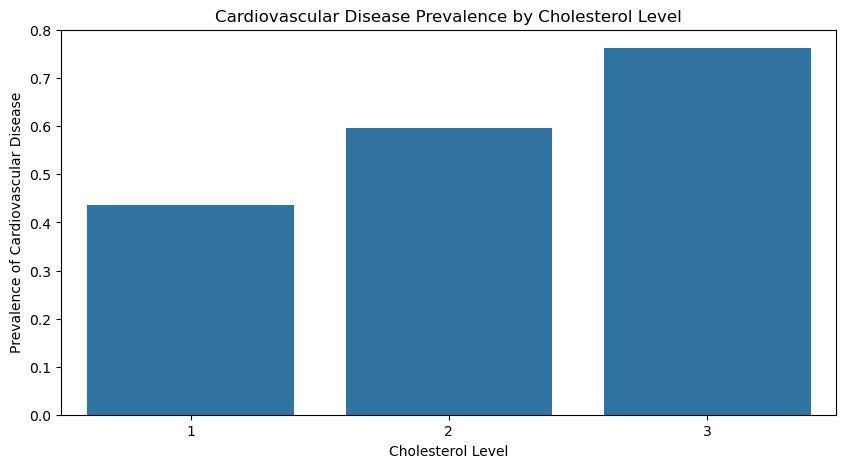

In [102]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=data_graph,
    x="cholesterol",
    y="cardio_prevalence"
)

plt.title("Cardiovascular Disease Prevalence by Cholesterol Level")
plt.xlabel("Cholesterol Level")
plt.ylabel("Prevalence of Cardiovascular Disease")

The prevalence of cardiovascular disease increases consistently across cholesterol levels. Each successive cholesterol category is associated with approximately a 20 percentage point increase in disease prevalence.

### 5.4 Blood Pressure and Cardiovascular Disease

In [ ]:
| categoría            | rango   |
| -------------------- | ------- |
| normal               | <120    |
| elevated             | 120–129 |
| stage 1 hypertension | 130–139 |
| stage 2 hypertension | 140–159 |
| severe               | 160+    |


<Axes: xlabel='cardio', ylabel='ap_hi'>

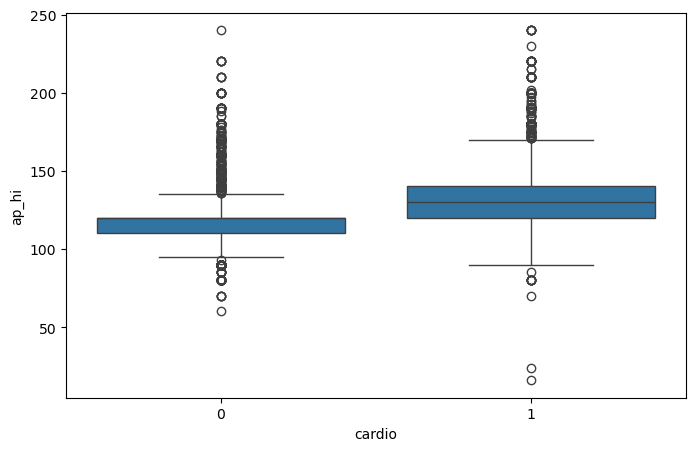

In [107]:
plt.figure(figsize=(8,5))
sns.boxplot(x="cardio", y="ap_hi", data=df_clean2)

<Axes: xlabel='cardio', ylabel='ap_lo'>

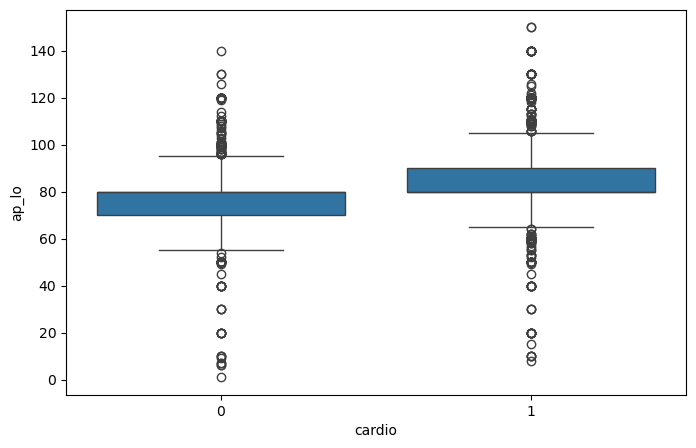

In [106]:
plt.figure(figsize=(8,5))
sns.boxplot(x="cardio", y="ap_lo", data=df_clean2)

The distribution of systolic blood pressure appears higher among patients with cardiovascular disease, suggesting a possible association between elevated blood pressure and cardiovascular risk.

In [108]:
df_clean2["bp_category"] = pd.cut(
    df_clean2["ap_hi"],
    bins=[0, 120, 130, 140, 160, 300],
    labels=[
        "Normal (<120)",
        "Elevated (120–129)",
        "Hypertension Stage 1 (130–139)",
        "Hypertension Stage 2 (140–159)",
        "Severe (160+)"
    ],
    right=False
)

In [114]:
data_graph2 = df_clean2.groupby("bp_category", observed=False)["cardio"].mean().reset_index().rename(columns={"cardio": "cardio_prevalence"})

Text(0, 0.5, 'Prevalence of Cardiovascular Disease')

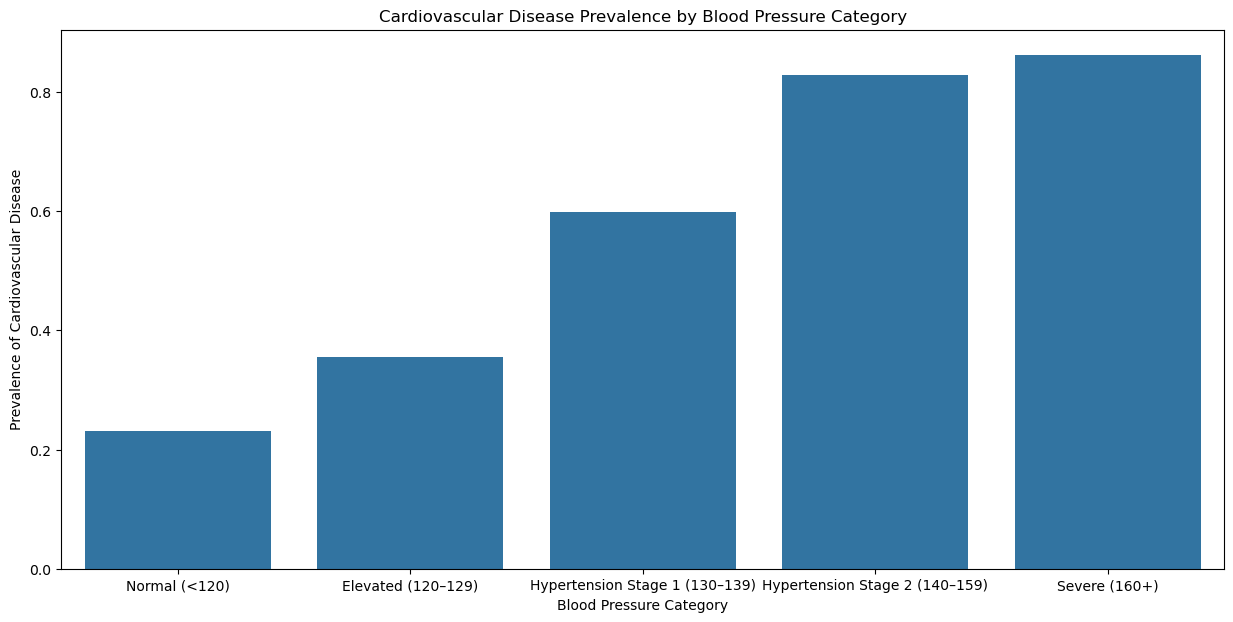

In [119]:
plt.figure(figsize=(15, 7))

sns.barplot(
    data=data_graph2,
    x="bp_category",
    y="cardio_prevalence"
)

plt.title("Cardiovascular Disease Prevalence by Blood Pressure Category")
plt.xlabel("Blood Pressure Category")
plt.ylabel("Prevalence of Cardiovascular Disease")

Cardiovascular disease prevalence increases sharply across systolic blood pressure categories. Patients in hypertensive ranges show substantially higher disease prevalence, exceeding 80% in stage 2 hypertension and severe hypertension groups.

In [121]:
data_graph3 = (
    df_clean2.
    groupby(["bp_category", "cholesterol"], observed=False)["cardio"]
    .mean()
    .reset_index()
    .rename(columns={"cardio": "cardio_prevalence"})
    )

In [123]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

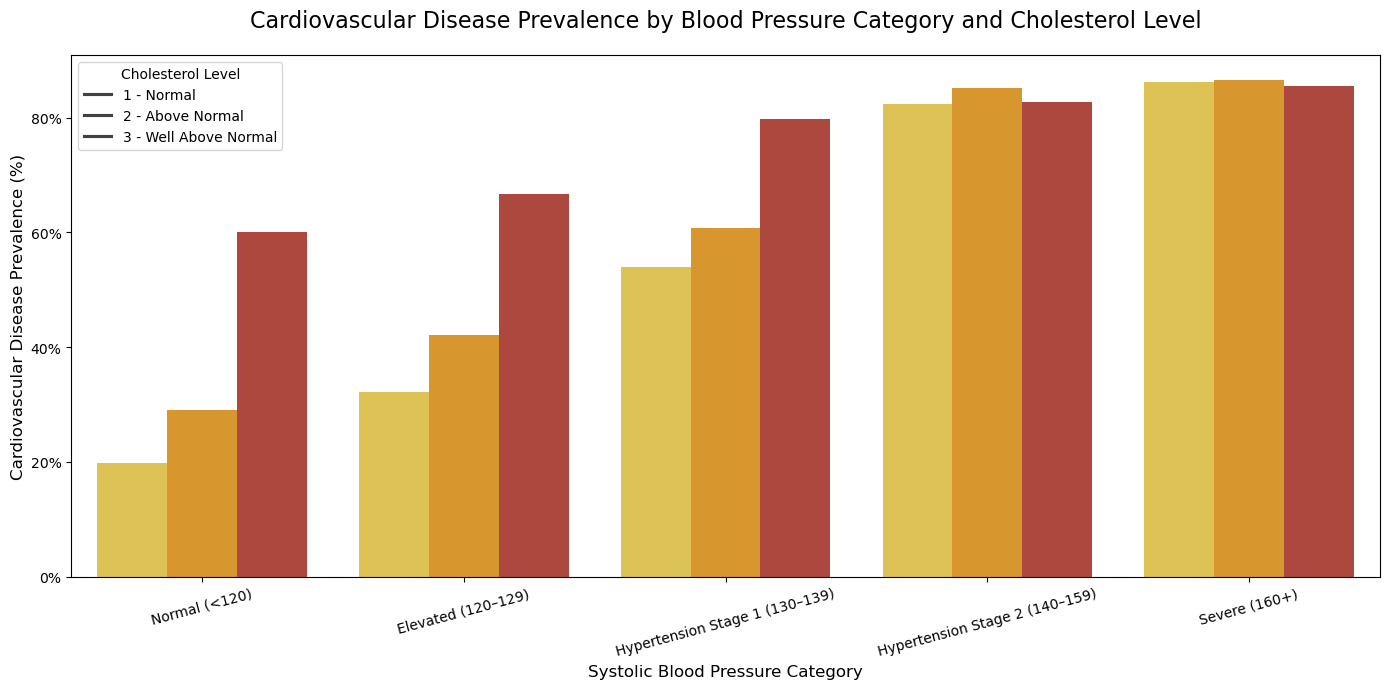

In [127]:
plt.figure(figsize=(14, 7))

ax = sns.barplot(
    data=data_graph3,
    x="bp_category",
    y="cardio_prevalence",
    hue="cholesterol",
    palette=["#F4D03F", "#F39C12", "#C0392B"]
)

plt.title(
    "Cardiovascular Disease Prevalence by Blood Pressure Category and Cholesterol Level",
    fontsize=16,
    pad=20
)


plt.xlabel("Systolic Blood Pressure Category", fontsize=12)
plt.ylabel("Cardiovascular Disease Prevalence (%)", fontsize=12)

plt.xticks(rotation=15)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.legend(
    title="Cholesterol Level",
    labels=["1 - Normal", "2 - Above Normal", "3 - Well Above Normal"]
)

plt.tight_layout()
plt.show()

The chart shows a clear increase in cardiovascular disease prevalence as both systolic blood pressure and cholesterol levels rise. Within each blood pressure category, higher cholesterol levels are generally associated with higher disease prevalence.

However, this pattern becomes less pronounced in the highest blood pressure categories (Hypertension Stage 2 and Severe). At these extreme levels of systolic blood pressure, the prevalence of cardiovascular disease is already very high across all cholesterol levels, and the differences between cholesterol categories become relatively small.

This suggests that while both elevated cholesterol and high blood pressure are associated with increased cardiovascular risk, extremely high blood pressure may dominate the risk profile, reducing the relative impact of cholesterol differences within those categories.

### 5.6 Body Mass Index (BMI) and Cardiovascular Disease

Body Mass Index (BMI) is a widely used indicator of body composition and a known risk factor for cardiovascular disease. 

To better understand the relationship between body weight and cardiovascular health, BMI is calculat

In [128]:
df_clean2 ["BMI"] = df_clean2["weight"] / (df_clean2["height"] / 100) ** 2

"""
| category    | BMI       |
| ----------- | --------- |
| Underweight | <18.5     |
| Normal      | 18.5–24.9 |
| Overweight  | 25–29.9   |
| Obese       | 30+       |

"""

In [133]:

df_clean2["bmi_category"] = pd.cut(
    df_clean2["BMI"],
    bins=[0, 18.5, 25, 30, 100],
    labels=[
        "Underweight",
        "Normal weight",
        "Overweight",
        "Obese"
    ],
    right=False
)

In [131]:
data_bmi = (
    df_clean2
    .groupby("bmi_category", observed=False)["cardio"]
    .mean()
    .reset_index()
    .rename(columns={"cardio": "cardio_prevalence"})
)

C:\Users\andre\AppData\Local\Temp\ipykernel_21764\3127229337.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


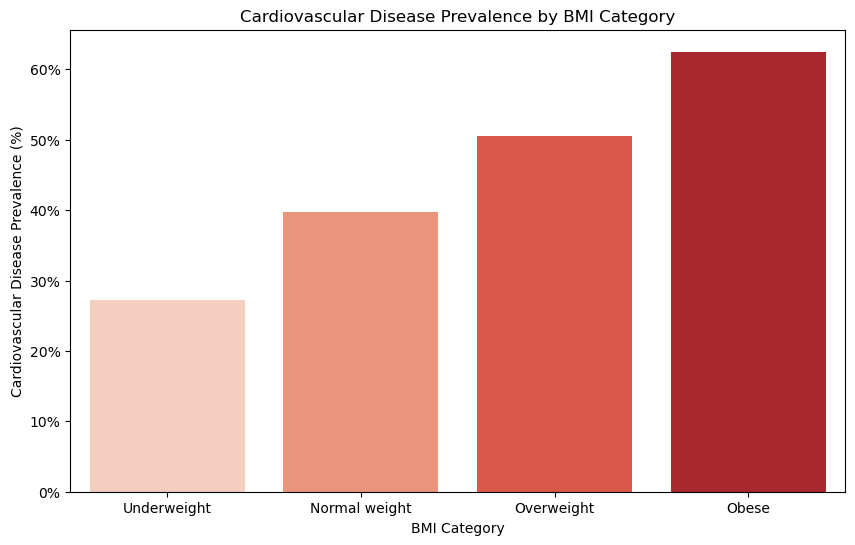

In [132]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=data_bmi,
    x="bmi_category",
    y="cardio_prevalence",
    palette="Reds"
)

plt.title("Cardiovascular Disease Prevalence by BMI Category")
plt.xlabel("BMI Category")
plt.ylabel("Cardiovascular Disease Prevalence (%)")

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.show()

Cardiovascular disease prevalence increases across BMI categories, with overweight and obese individuals showing substantially higher disease prevalence. This pattern is consistent with established medical evidence linking excess body weight with elevated cardiovascular risk.

### 5.8 Lifestyles facotrs and Cardiovascular Disease

Lifestyle behaviors such as smoking, alcohol consumption, and physical activity are important determinants of cardiovascular health. 

To explore their association with cardiovascular disease, the prevalence of the target variable is analyzed across these lifestyle-related variables.

C:\Users\andre\AppData\Local\Temp\ipykernel_21764\1887322500.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


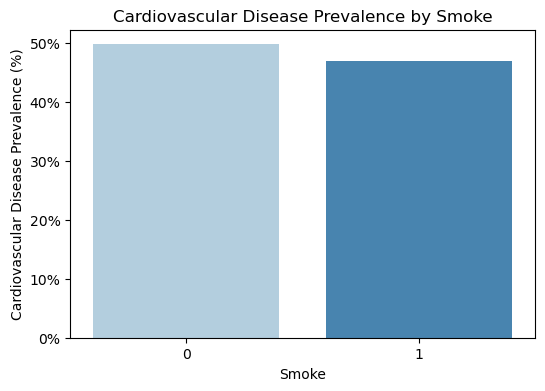

C:\Users\andre\AppData\Local\Temp\ipykernel_21764\1887322500.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


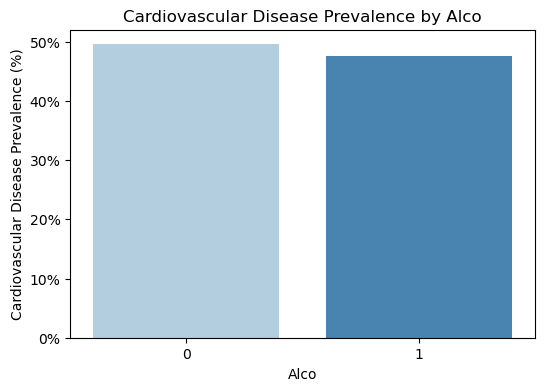

C:\Users\andre\AppData\Local\Temp\ipykernel_21764\1887322500.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


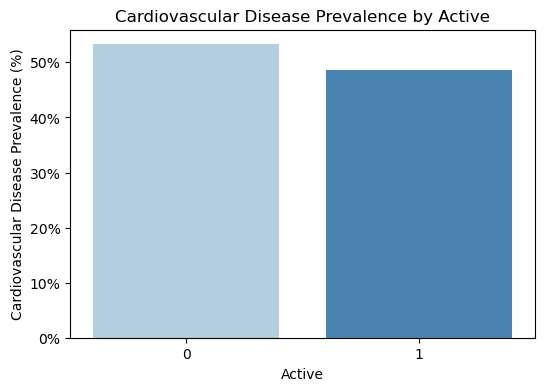

In [135]:
lifestyle_vars = ["smoke", "alco", "active"]

for var in lifestyle_vars:
    
    data_lifestyle = (
        df_clean2
        .groupby(var)["cardio"]
        .mean()
        .reset_index()
        .rename(columns={"cardio": "cardio_prevalence"})
    )
    
    plt.figure(figsize=(6,4))
    
    sns.barplot(
        data=data_lifestyle,
        x=var,
        y="cardio_prevalence",
        palette="Blues"
    )
    
    plt.title(f"Cardiovascular Disease Prevalence by {var.capitalize()}")
    plt.xlabel(var.capitalize())
    plt.ylabel("Cardiovascular Disease Prevalence (%)")
    
    plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    
    plt.show()

### 5.9 Summary of Key Findings

The exploratory analysis reveals several clear patterns associated with cardiovascular disease in the dataset.

First, age shows a strong relationship with cardiovascular disease prevalence, with older individuals displaying significantly higher rates of the condition.

Second, both cholesterol level and systolic blood pressure demonstrate strong associations with cardiovascular disease. Higher cholesterol categories correspond to higher disease prevalence, while increasing blood pressure categories show a dramatic rise in cardiovascular risk, particularly in hypertensive ranges.

The interaction analysis between blood pressure and cholesterol suggests a compounding effect of these risk factors. In most blood pressure categories, higher cholesterol levels correspond to higher disease prevalence. However, at very high blood pressure levels, cardiovascular disease prevalence becomes extremely high across all cholesterol categories, suggesting that severe hypertension may dominate the risk profile.

Body Mass Index (BMI) also shows a positive relationship with cardiovascular disease, with overweight and obese individuals presenting higher disease prevalence compared to normal-weight individuals.

Finally, lifestyle variables such as smoking, alcohol consumption, and physical activity show weaker but still observable associations with cardiovascular disease prevalence.

Overall, the exploratory analysis highlights blood pressure, cholesterol level, age, and body composition as the strongest factors associated with cardiovascular disease in this dataset.

These findings provide useful insight into the main factors associated with cardiovascular disease in the dataset. In particular, age, blood pressure, cholesterol level, and body composition appear to play important roles.

The insights obtained from this exploratory analysis will guide the feature preparation and modeling steps in the following sections.